## **Notebook 02: Dynamic Routing with Conditional Edges**

### **Setup**

In [16]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Literal

print("✅ Imports successful!")
print("🔀 Ready to build conditional workflows!")

✅ Imports successful!
🔀 Ready to build conditional workflows!


### **Example 1: Content Classifier**

In [17]:
# Define state
class ContentState(TypedDict):
    text: str
    score: float  # 0.0 to 1.0
    category: str
    message: str

In [18]:
# Node: Analyze content and assign a score
def analyze_content(state: ContentState) -> dict:
    """Simulate content analysis with a simple scoring system."""
    print(f"🔍 Analyzing content: '{state['text'][:50]}...'")
    
    # Simple scoring: count "good" vs "bad" keywords
    text_lower = state["text"].lower()
    good_words = ["great", "excellent", "amazing", "helpful", "good"]
    bad_words = ["spam", "scam", "fake", "terrible", "hate"]
    
    good_count = sum(word in text_lower for word in good_words)
    bad_count = sum(word in text_lower for word in bad_words)
    
    # Calculate score
    if good_count + bad_count == 0:
        score = 0.5  # Neutral
    else:
        score = good_count / (good_count + bad_count)
    
    print(f"📊 Content score: {score:.2f}")
    return {"score": score}

# Routing function: Decides which path to take
def route_content(state: ContentState) -> Literal["approve", "reject", "review"]:
    """Route content based on score."""
    score = state["score"]
    
    if score >= 0.7:
        print("✅ Routing to APPROVE")
        return "approve"
    elif score < 0.3:
        print("❌ Routing to REJECT")
        return "reject"
    else:
        print("⚠️  Routing to REVIEW")
        return "review"
    
# Terminal nodes for each path
def approve_content(state: ContentState) -> dict:
    """Approve the content."""
    print("✅ Content APPROVED")
    return {
        "category": "approved",
        "message": "Content approved for publication"
    }

def reject_content(state: ContentState) -> dict:
    """Reject the content."""
    print("❌ Content REJECTED")
    return {
        "category": "rejected",
        "message": "Content does not meet quality standards"
    }

def review_content(state: ContentState) -> dict:
    """Flag for manual review."""
    print("⚠️  Content flagged for REVIEW")
    return {
        "category": "review",
        "message": "Content requires manual review"
    }

In [19]:
# Build graph
content_graph = StateGraph(ContentState)

# Add nodes
content_graph.add_node("analyze", analyze_content)
content_graph.add_node("approve", approve_content)
content_graph.add_node("reject", reject_content)
content_graph.add_node("review", review_content)

# Add edges
content_graph.add_edge(START, "analyze")

# CONDITIONAL EDGE: The key new concept!
content_graph.add_conditional_edges(
    "analyze",           # Source node
    route_content,       # Routing function
    # The routing function returns one of these node names:
    # - "approve", "reject", or "review"
)

# Each terminal node goes to END
content_graph.add_edge("approve", END)
content_graph.add_edge("reject", END)
content_graph.add_edge("review", END)

# Compile
content_app = content_graph.compile()

print("✅ Content classifier ready!")

✅ Content classifier ready!


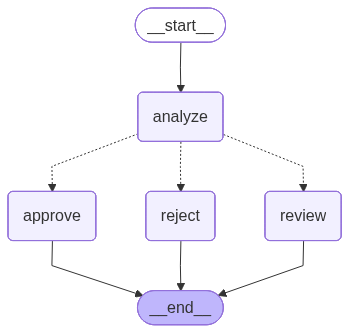

In [20]:
from IPython.display import Image, display

try:
    display(Image(content_app.get_graph().draw_mermaid_png()))
except Exception as e:
    # Fallback: print Mermaid text
    print(content_app.get_graph().draw_mermaid())

In [21]:
# Test 1: Positive content (should be approved)
print("=" * 60)
print("TEST 1: Positive Content")
print("=" * 60)

result1 = content_app.invoke({
    "text": "This is a great and amazing product! Excellent quality and very helpful.",
    "score": 0.0,
    "category": "",
    "message": ""
})

print(f"\n📝 Result: {result1['category'].upper()}")
print(f"💬 Message: {result1['message']}\n")

TEST 1: Positive Content
🔍 Analyzing content: 'This is a great and amazing product! Excellent qua...'
📊 Content score: 1.00
✅ Routing to APPROVE
✅ Content APPROVED

📝 Result: APPROVED
💬 Message: Content approved for publication



In [22]:
# Test 2: Negative content (should be rejected)
print("=" * 60)
print("TEST 2: Negative Content")
print("=" * 60)

result2 = content_app.invoke({
    "text": "This is spam! Terrible scam, fake product. I hate it.",
    "score": 0.0,
    "category": "",
    "message": ""
})

print(f"\n📝 Result: {result2['category'].upper()}")
print(f"💬 Message: {result2['message']}\n")

TEST 2: Negative Content
🔍 Analyzing content: 'This is spam! Terrible scam, fake product. I hate ...'
📊 Content score: 0.00
❌ Routing to REJECT
❌ Content REJECTED

📝 Result: REJECTED
💬 Message: Content does not meet quality standards



In [23]:
# Test 3: Neutral content (should be reviewed)
print("=" * 60)
print("TEST 3: Neutral Content")
print("=" * 60)

result3 = content_app.invoke({
    "text": "This product is okay. Some good features, but also some terrible aspects.",
    "score": 0.0,
    "category": "",
    "message": ""
})

print(f"\n📝 Result: {result3['category'].upper()}")
print(f"💬 Message: {result3['message']}\n")

TEST 3: Neutral Content
🔍 Analyzing content: 'This product is okay. Some good features, but also...'
📊 Content score: 0.50
⚠️  Routing to REVIEW
⚠️  Content flagged for REVIEW

📝 Result: REVIEW
💬 Message: Content requires manual review



### **Example 2: Grade-Based Feedback System**

In [24]:
class GradeState(TypedDict):
    student_name: str
    score: int        # 0-100
    letter_grade: str # A, B, C, D, F
    feedback: str
    action_required: str

In [25]:
def calculate_grade(state: GradeState) -> dict:
    """Convert numerical score to letter grade."""
    score = state["score"]
    print(f"📊 Calculating grade for {state['student_name']}: {score}/100")
    
    if score >= 90:
        letter = "A"
    elif score >= 80:
        letter = "B"
    elif score >= 70:
        letter = "C"
    elif score >= 60:
        letter = "D"
    else:
        letter = "F"
    
    print(f"📝 Letter grade: {letter}")
    return {"letter_grade": letter}


def route_by_grade(state: GradeState) -> Literal["excellent", "good", "needs_work", "remedial"]:
    """Route to different feedback based on grade."""
    grade = state["letter_grade"]
    
    routes = {
        "A": "excellent",
        "B": "good",
        "C": "needs_work",
        "D": "remedial",
        "F": "remedial"
    }
    
    route = routes[grade]
    print(f"🔀 Routing to: {route.upper()}")
    return route


def excellent_feedback(state: GradeState) -> dict:
    return {
        "feedback": f"Outstanding work, {state['student_name']}! Keep up the excellent performance!",
        "action_required": "None - consider for honors program"
    }

def good_feedback(state: GradeState) -> dict:
    return {
        "feedback": f"Good job, {state['student_name']}! You're on the right track.",
        "action_required": "Continue current approach"
    }

def needs_work_feedback(state: GradeState) -> dict:
    return {
        "feedback": f"{state['student_name']}, you're passing but could improve with more practice.",
        "action_required": "Recommend extra practice sessions"
    }

def remedial_feedback(state: GradeState) -> dict:
    return {
        "feedback": f"{state['student_name']}, we need to address some fundamental gaps.",
        "action_required": "Schedule tutoring and re-assessment"
    }

In [26]:
grade_graph = StateGraph(GradeState)

grade_graph.add_node("calculate", calculate_grade)
grade_graph.add_node("excellent", excellent_feedback)
grade_graph.add_node("good", good_feedback)
grade_graph.add_node("needs_work", needs_work_feedback)
grade_graph.add_node("remedial", remedial_feedback)

grade_graph.add_edge(START, "calculate")
grade_graph.add_conditional_edges("calculate", route_by_grade)

grade_graph.add_edge("excellent", END)
grade_graph.add_edge("good", END)
grade_graph.add_edge("needs_work", END)
grade_graph.add_edge("remedial", END)

grade_app = grade_graph.compile()

print("✅ Grade feedback system ready!")

✅ Grade feedback system ready!


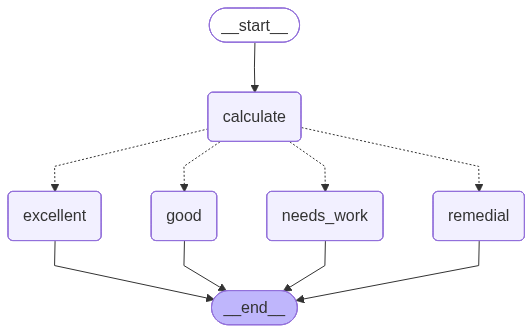

In [27]:
from IPython.display import Image, display

try:
    display(Image(grade_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(grade_app.get_graph().draw_mermaid())

In [28]:
test_students = [
    {"student_name": "Alice", "score": 95},
    {"student_name": "Bob", "score": 82},
    {"student_name": "Charlie", "score": 71},
    {"student_name": "Diana", "score": 55}
]

for student in test_students:
    print("\n" + "=" * 60)
    result = grade_app.invoke({
        "student_name": student["student_name"],
        "score": student["score"],
        "letter_grade": "",
        "feedback": "",
        "action_required": ""
    })
    
    print(f"\n🎓 Grade: {result['letter_grade']}")
    print(f"💬 {result['feedback']}")
    print(f"📋 Action: {result['action_required']}")


📊 Calculating grade for Alice: 95/100
📝 Letter grade: A
🔀 Routing to: EXCELLENT

🎓 Grade: A
💬 Outstanding work, Alice! Keep up the excellent performance!
📋 Action: None - consider for honors program

📊 Calculating grade for Bob: 82/100
📝 Letter grade: B
🔀 Routing to: GOOD

🎓 Grade: B
💬 Good job, Bob! You're on the right track.
📋 Action: Continue current approach

📊 Calculating grade for Charlie: 71/100
📝 Letter grade: C
🔀 Routing to: NEEDS_WORK

🎓 Grade: C
💬 Charlie, you're passing but could improve with more practice.
📋 Action: Recommend extra practice sessions

📊 Calculating grade for Diana: 55/100
📝 Letter grade: F
🔀 Routing to: REMEDIAL

🎓 Grade: F
💬 Diana, we need to address some fundamental gaps.
📋 Action: Schedule tutoring and re-assessment


### **Example 3: API Response Handler**

In [29]:
import random

class APIState(TypedDict):
    url: str
    status_code: int
    retry_count: int
    max_retries: int
    data: str
    result: str

def call_api(state: APIState) -> dict:
    """Simulate an API call that might succeed or fail."""
    print(f"🌐 Calling API: {state['url']} (Attempt {state['retry_count'] + 1})")
    
    # Simulate random responses
    outcomes = [200, 200, 500, 503]  # Weighted towards success
    status = random.choice(outcomes)
    
    print(f"📡 Response: {status}")
    
    if status == 200:
        return {"status_code": status, "data": "Success data payload"}
    else:
        return {"status_code": status, "data": ""}
    

def check_status(state: APIState) -> Literal["success", "retry", "error"]:
    """Route based on API response status."""
    status = state["status_code"]
    retry_count = state["retry_count"]
    max_retries = state["max_retries"]
    
    if status == 200:
        print("✅ Success! Routing to process_data")
        return "success"
    elif status in [500, 503] and retry_count < max_retries:
        print(f"⚠️  Retryable error. Routing to retry ({retry_count + 1}/{max_retries})")
        return "retry"
    else:
        print("❌ Fatal error or max retries exceeded. Routing to error handler")
        return "error"
    
def process_data(state: APIState) -> dict:
    """Process successful API response."""
    print("✅ Processing data...")
    return {"result": f"Processed: {state['data']}"}

def retry_request(state: APIState) -> dict:
    """Prepare for retry."""
    new_retry_count = state["retry_count"] + 1
    print(f"🔄 Preparing retry {new_retry_count}...")
    return {"retry_count": new_retry_count}

def handle_error(state: APIState) -> dict:
    """Handle fatal errors."""
    print("❌ Handling fatal error...")
    return {"result": f"Error {state['status_code']}: Request failed after {state['retry_count']} retries"}

In [30]:
# Build API handler graph
api_graph = StateGraph(APIState)

# Add nodes
api_graph.add_node("call", call_api)
api_graph.add_node("success", process_data)
api_graph.add_node("retry", retry_request)
api_graph.add_node("error", handle_error)

# Add edges
api_graph.add_edge(START, "call")
api_graph.add_conditional_edges("call", check_status)

# Success and error go to END
api_graph.add_edge("success", END)
api_graph.add_edge("error", END)

# Retry loops back to call! This creates a cycle.
api_graph.add_edge("retry", "call")

api_app = api_graph.compile()

print("✅ API handler ready!")

✅ API handler ready!


In [31]:
from IPython.display import Markdown, display

mermaid_text = grade_app.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_text}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	calculate(calculate)
	excellent(excellent)
	good(good)
	needs_work(needs_work)
	remedial(remedial)
	__end__([<p>__end__</p>]):::last
	__start__ --> calculate;
	calculate -.-> excellent;
	calculate -.-> good;
	calculate -.-> needs_work;
	calculate -.-> remedial;
	excellent --> __end__;
	good --> __end__;
	needs_work --> __end__;
	remedial --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

In [32]:
# Test the API handler
print("=" * 60)
print("Testing API Handler with Retries")
print("=" * 60)

result = api_app.invoke({
    "url": "https://api.example.com/data",
    "status_code": 0,
    "retry_count": 0,
    "max_retries": 3,
    "data": "",
    "result": ""
})

print("\n" + "=" * 60)
print(f"📊 Final Result: {result['result']}")
print(f"🔢 Total Attempts: {result['retry_count'] + 1}")
print("=" * 60)

Testing API Handler with Retries
🌐 Calling API: https://api.example.com/data (Attempt 1)
📡 Response: 500
⚠️  Retryable error. Routing to retry (1/3)
🔄 Preparing retry 1...
🌐 Calling API: https://api.example.com/data (Attempt 2)
📡 Response: 200
✅ Success! Routing to process_data
✅ Processing data...

📊 Final Result: Processed: Success data payload
🔢 Total Attempts: 2


### **Hands-on Exercise: Email Triage System**

In [33]:
class EmailState(TypedDict):
    sender: str
    subject: str
    content: str
    classification: str
    action_taken: str


In [34]:
def classify_email(state: EmailState) -> dict:
    text = (state["subject"] + " " + state["content"] + " " + state["sender"]).lower()
    
    if any(word in text for word in ["urgent", "asap", "emergency"]):
        classification = "URGENT"
    elif any(word in text for word in ["win", "prize", "click here", "congratulations"]):
        classification = "SPAM"
    elif "noreply" in text or "automated" in text:
        classification = "AUTOMATED"
    else:
        classification = "NORMAL"
    
    return {"classification": classification}

def route_email(state: EmailState) -> Literal["urgent", "spam", "automated", "normal"]:
    routes = {
        "URGENT": "urgent",
        "SPAM": "spam",
        "AUTOMATED": "automated",
        "NORMAL": "normal"
    }
    return routes[state["classification"]]

def escalate_to_priority(state: EmailState) -> dict:
    return {"action_taken": "Escalated to priority queue for immediate attention"}

def delete_email(state: EmailState) -> dict:
    return {"action_taken": "Moved to spam folder"}

def auto_respond(state: EmailState) -> dict:
    return {"action_taken": "Auto-response sent, email archived"}

def standard_processing(state: EmailState) -> dict:
    return {"action_taken": "Added to inbox for standard processing"}

In [35]:
email_graph = StateGraph(EmailState)
email_graph.add_node("classify", classify_email)
email_graph.add_node("urgent", escalate_to_priority)
email_graph.add_node("spam", delete_email)
email_graph.add_node("automated", auto_respond)
email_graph.add_node("normal", standard_processing)

email_graph.add_edge(START, "classify")
email_graph.add_conditional_edges("classify", route_email)
email_graph.add_edge("urgent", END)
email_graph.add_edge("spam", END)
email_graph.add_edge("automated", END)
email_graph.add_edge("normal", END)

email_app = email_graph.compile()

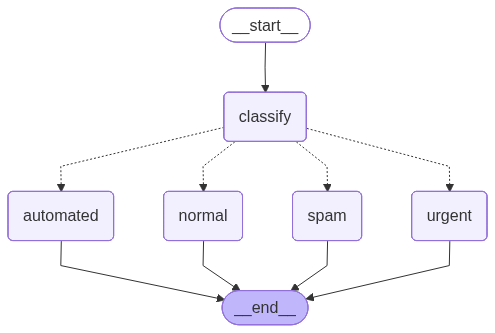

In [36]:
from IPython.display import Image, display

try:
    display(Image(email_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(email_app.get_graph().draw_mermaid())

In [37]:
test_emails = [
    {
        "sender": "boss@company.com",
        "subject": "URGENT: Server down!",
        "content": "We need this fixed ASAP!"
    },
    {
        "sender": "spam@lottery.com",
        "subject": "You won a prize!",
        "content": "Click here to claim your prize. Congratulations!"
    },
    {
        "sender": "noreply@service.com",
        "subject": "Account notification",
        "content": "This is an automated message."
    },
    {
        "sender": "colleague@company.com",
        "subject": "Meeting tomorrow",
        "content": "Let's discuss the project."
    }
]

#Uncomment to test:
for email in test_emails:
    result = email_app.invoke({
        **email,
        "classification": "",
        "action_taken": ""
    })
    print(f"\nEmail: {result['subject']}")
    print(f"Classification: {result['classification']}")
    print(f"Action: {result['action_taken']}")
    print("-" * 60)


Email: URGENT: Server down!
Classification: URGENT
Action: Escalated to priority queue for immediate attention
------------------------------------------------------------

Email: You won a prize!
Classification: SPAM
Action: Moved to spam folder
------------------------------------------------------------

Email: Account notification
Classification: AUTOMATED
Action: Auto-response sent, email archived
------------------------------------------------------------

Email: Meeting tomorrow
Classification: NORMAL
Action: Added to inbox for standard processing
------------------------------------------------------------


### **LangGraph 1.1.9: The Command Class — A Concise Alternative**

In [38]:
#Command approach (new, concise):
class State(TypedDict):
    text: str

def compute_score(score):
    pass

from langgraph.types import Command

def analyze(state: State) -> Command:
    score = compute_score(state["text"])
    return Command(
        update={"score": score},        # state update
        goto="approve" if score >= 0.7 else "reject",  # routing
    )

In [39]:
# Command example — conditional routing + state update in one return
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import Literal
from typing_extensions import TypedDict

class ContentState(TypedDict):
    text: str
    score: float
    result: str

In [40]:
def analyze_and_route(state: ContentState) -> Command:
    """Analyze content and route — combined in one node."""
    # Simulate scoring
    score = len(state["text"]) / 100  # simplified score
    score = min(score, 1.0)

    if score >= 0.7:
        destination = "approve"
    elif score >= 0.3:
        destination = "review"
    else:
        destination = "reject"

    print(f"📊 Score: {score:.2f} → routing to '{destination}'")
    return Command(update={"score": score}, goto=destination)

def approve(state: ContentState) -> dict:
    return {"result": f"✅ APPROVED (score: {state['score']:.2f})"}

def review(state: ContentState) -> dict:
    return {"result": f"🔍 NEEDS REVIEW (score: {state['score']:.2f})"}

def reject(state: ContentState) -> dict:
    return {"result": f"❌ REJECTED (score: {state['score']:.2f})"}

In [41]:
graph = StateGraph(ContentState)
graph.add_node("analyze", analyze_and_route)
graph.add_node("approve", approve)
graph.add_node("review", review)
graph.add_node("reject", reject)

graph.add_edge(START, "analyze")
graph.add_edge("approve", END)
graph.add_edge("review", END)
graph.add_edge("reject", END)

app = graph.compile()

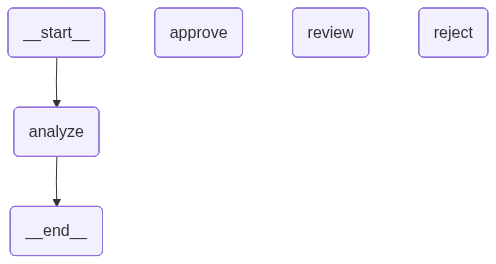

In [42]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(app.get_graph().draw_mermaid())

In [43]:
result = app.invoke({
    "text": "This is a long and detailed piece of content that deserves careful review and consideration.",
    "score": 0.0,
    "result": ""
})
print(result["result"])

📊 Score: 0.92 → routing to 'approve'
✅ APPROVED (score: 0.92)


### **Parallel Edges - FAN IN FAN OUT**

In [44]:
import os
import operator
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langchain_openai import AzureChatOpenAI
from dotenv import load_dotenv
load_dotenv()

True

In [45]:
# ------------------------------------------------------------
# LLM
# ------------------------------------------------------------
llm = AzureChatOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    temperature=0.7,
)

print(llm.invoke("hello"))

content='Hello! How can I assist you today? 😊' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 8, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 6, 'engine_ttft_ms': 44, 'engine_ttlt_ms': 106, 'pre_inference_ms': 98, 'service_tbt_ms': 13, 'service_ttft_ms': 386, 'service_ttlt_ms': 489, 'total_duration_ms': 432, 'user_visible_ttft_ms': 288}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_9baf9886c5', 'id': 'chatcmpl-E2f7XOlx8ChN1v9oIgfaAoBBigEzq', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': F

In [46]:
# ------------------------------------------------------------
# STATE
# ------------------------------------------------------------

class State(TypedDict):
    topic: str
    sections: Annotated[list[str], operator.add]
    final_post: str

In [47]:
# ------------------------------------------------------------
# NODES
# ------------------------------------------------------------

def prepare_topic(state: State):
    print(f"\n📋 Preparing blog about: {state['topic']}")
    return {}

# ---------------- PARALLEL NODE 1 ----------------

def write_intro(state: State):

    prompt = f"""
    Write an engaging blog introduction about:
    {state['topic']}

    Keep it concise and professional.
    """

    response = llm.invoke(prompt)

    return {
        "sections": [f"# Introduction\n\n{response.content}"]
    }


# ---------------- PARALLEL NODE 2 ----------------

def write_body(state: State):

    prompt = f"""
    Write the main body of a blog about:
    {state['topic']}

    Include:
    - Top use cases
    - Industry applications
    - Real-world impact

    Use markdown formatting.
    """

    response = llm.invoke(prompt)

    return {
        "sections": [f"# Main Content\n\n{response.content}"]
    }


# ---------------- PARALLEL NODE 3 ----------------

def write_conclusion(state: State):

    prompt = f"""
    Write a strong conclusion for a blog about:
    {state['topic']}

    Mention future implications and trends.
    """

    response = llm.invoke(prompt)

    return {
        "sections": [f"# Conclusion\n\n{response.content}"]
    }

In [48]:
# ------------------------------------------------------------
# FAN-IN
# ------------------------------------------------------------

def assemble_post(state: State):

    print("\n🔗 Combining all sections...")

    full_post = "\n\n".join(state["sections"])

    return {
        "final_post": full_post
    }

In [49]:

# ------------------------------------------------------------
# GRAPH
# ------------------------------------------------------------

builder = StateGraph(State)

builder.add_node("prepare_topic", prepare_topic)

builder.add_node("write_intro", write_intro)
builder.add_node("write_body", write_body)
builder.add_node("write_conclusion", write_conclusion)

builder.add_node("assemble_post", assemble_post)

builder.add_edge(START, "prepare_topic")

# FAN-OUT
builder.add_edge("prepare_topic", "write_intro")
builder.add_edge("prepare_topic", "write_body")
builder.add_edge("prepare_topic", "write_conclusion")

# FAN-IN
builder.add_edge("write_intro", "assemble_post")
builder.add_edge("write_body", "assemble_post")
builder.add_edge("write_conclusion", "assemble_post")

builder.add_edge("assemble_post", END)

In [50]:
# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

graph = builder.compile()

mermaid_text = graph.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_text}\n```"))

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	prepare_topic(prepare_topic)
	write_intro(write_intro)
	write_body(write_body)
	write_conclusion(write_conclusion)
	assemble_post(assemble_post)
	__end__([<p>__end__</p>]):::last
	__start__ --> prepare_topic;
	prepare_topic --> write_body;
	prepare_topic --> write_conclusion;
	prepare_topic --> write_intro;
	write_body --> assemble_post;
	write_conclusion --> assemble_post;
	write_intro --> assemble_post;
	assemble_post --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

In [51]:
# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

result = graph.invoke({
    "topic": "How Agentic AI is Transforming Software Engineering",
    "sections": [],
    "final_post": "",
})

print("\n📝 FINAL BLOG:\n")
print(result["final_post"])


📋 Preparing blog about: How Agentic AI is Transforming Software Engineering

🔗 Combining all sections...

📝 FINAL BLOG:

# Main Content

# How Agentic AI is Transforming Software Engineering

The rise of agentic AI, where artificial intelligence systems can operate autonomously, make decisions, and take actions without continuous human supervision, is reshaping the software engineering landscape. From automating tedious coding tasks to optimizing system performance in real-time, agentic AI is proving to be a game-changer. In this blog, we explore the top use cases, industry applications, and real-world impact of agentic AI in software engineering.

---

## Top Use Cases of Agentic AI in Software Engineering

Agentic AI is not just a buzzword; it is being actively deployed to solve real-world problems in software development and maintenance. Here are some of the most impactful use cases:

### 1. **Automated Code Generation and Debugging**
Agentic AI can autonomously write, refactor, an